# Transformer 기반 한국어 → 영어 번역기

**[과제명]** Transformer로 만드는 한-영 번역기
**[날짜]** 2026-09-10
**[목표]** Transformer 구조를 PyTorch로 직접 구현하여 한국어→영어 번역기를 학습하고, Attention Map으로 결과를 뒷받침한다.


## 이 노트북의 구성 (루브릭 대응)
1. **데이터 전처리** — 이미 언팩된 한국어-영어 병렬 코퍼스 로드, 중복 제거, 정제(clean)
2. **토큰화** — SentencePiece로 한국어/영어 각각 서브워드 토크나이저 학습, 데이터셋 구축
3. **Transformer 모델 정의** — Positional Encoding, Multi-Head Attention, Encoder/Decoder, 마스킹
4. **학습 & 추론** — Noam 학습률 스케줄, teacher forcing 학습, greedy decoding 추론
5. **결과 확인** — 번역 품질 확인 + Attention Map 시각화




In [9]:
"""
[과제명] Transformer 한-영 번역기
[날짜] 2026-09-10
[목표] Transformer를 직접 구현해 한국어 -> 영어 번역기를 학습하고 Attention을 시각화한다

"""


import os        # 경로 조작 (DATA_DIR 등) — 원본 스켈레톤에는 import가 빠져 있어서 추가함
import re        # 정규식 기반 문장 정제 (preprocess_sentence)
import math      # Positional Encoding의 sin/cos 계산, sqrt(d_model) 스케일링
import random    # 매 epoch 마다 배치 순서를 섞기 위한 random.shuffle

import torch
import torch.nn as nn
import torch.optim as optim
import numpy
import matplotlib
import matplotlib.pyplot as plt
import seaborn

from tqdm import tqdm

# 로컬 Jupyter(venv) 환경에서도 그래프가 셀 출력에 바로 그려지도록 명시적으로 설정한다.
# (JupyterLab/최신 Notebook은 기본값이지만, 구버전 설정에서는 이 매직이 없으면 그림이 안 뜰 수 있다)
%matplotlib inline

print("torch     :", torch.__version__)
print("numpy     :", numpy.__version__)
print("matplotlib:", matplotlib.__version__)

# --- 재현성을 위한 시드 고정 ---
# [주의] 완전한 재현성을 보장하진 않지만(GPU 연산의 비결정성 때문), 대략적인 재현에는 충분하다.
SEED = 42
random.seed(SEED)
numpy.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# GPU가 있으면 GPU를, 없으면 CPU를 사용한다. 원본 스켈레톤에서 device를 쓰지만 정의가 빠져 있어 추가함.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device    :", device)


torch     : 2.14.0+cu126
numpy     : 2.5.3
matplotlib: 3.11.1
device    : cuda


## 1. 데이터 로드

[jungyeul/korean-parallel-corpora](https://github.com/jungyeul/korean-parallel-corpora) 의 뉴스 병렬 코퍼스(`korean-english-park.train`)를 사용한다.

이 노트북과 같은 폴더에 이미 언팩된 아래 파일을 절대 경로로 읽는다.

- `C:\Users\singf\Desktop\아이펠 모음\transformer\korean-english-park.train (1)\korean-english-park.train.ko`
- `C:\Users\singf\Desktop\아이펠 모음\transformer\korean-english-park.train (1)\korean-english-park.train.en`

SentencePiece 모델·중간 코퍼스 파일은 `C:\Users\singf\Desktop\아이펠 모음\transformer\data` 에 저장한다.



In [10]:
# --- 1. 데이터 로드 ---
# 이 노트북과 같은 transformer 폴더의 언팩된 병렬 코퍼스를 절대 경로로 사용한다.
# Colab / 다운로드 / 압축 해제 없음.

NOTEBOOK_DIR = r"C:\Users\singf\Desktop\아이펠 모음\transformer"
CORPUS_DIR = os.path.join(NOTEBOOK_DIR, "korean-english-park.train (1)")
DATA_DIR = os.path.join(NOTEBOOK_DIR, "data")

kor_path = os.path.join(CORPUS_DIR, "korean-english-park.train.ko")
eng_path = os.path.join(CORPUS_DIR, "korean-english-park.train.en")

os.makedirs(DATA_DIR, exist_ok=True)

assert os.path.isdir(NOTEBOOK_DIR), f"노트북 폴더가 없습니다: {NOTEBOOK_DIR}"
assert os.path.isdir(CORPUS_DIR), f"코퍼스 폴더가 없습니다: {CORPUS_DIR}"
assert os.path.isfile(kor_path), f"한국어 파일이 없습니다: {kor_path}"
assert os.path.isfile(eng_path), f"영어 파일이 없습니다: {eng_path}"

print("NOTEBOOK_DIR:", NOTEBOOK_DIR)
print("CORPUS_DIR  :", CORPUS_DIR)
print("kor_path    :", kor_path)
print("eng_path    :", eng_path)
print("DATA_DIR    :", DATA_DIR)


NOTEBOOK_DIR: C:\Users\singf\Desktop\아이펠 모음\transformer
CORPUS_DIR  : C:\Users\singf\Desktop\아이펠 모음\transformer\korean-english-park.train (1)
kor_path    : C:\Users\singf\Desktop\아이펠 모음\transformer\korean-english-park.train (1)\korean-english-park.train.ko
eng_path    : C:\Users\singf\Desktop\아이펠 모음\transformer\korean-english-park.train (1)\korean-english-park.train.en
DATA_DIR    : C:\Users\singf\Desktop\아이펠 모음\transformer\data


## 2. 데이터 정제 (Cleaning)

두 파일은 줄 번호가 서로 대응하는 병렬 코퍼스다 (`kor[i]` ↔ `eng[i]`). 먼저 (한국어, 영어) 쌍 단위로 중복을 제거한다.
`Chest.txt`에 기록해 둔 "set + zip으로 중복 제거" 패턴을 그대로 사용한다.


In [11]:
# --- 2. 데이터 정제 ---

def clean_corpus(kor_path, eng_path):
    """
    한국어/영어 병렬 코퍼스 파일을 읽어 (한국어, 영어) 쌍 단위로 중복을 제거한다.

    Args:
        kor_path (str): 한국어 문장 파일 경로 (한 줄에 한 문장)
        eng_path (str): 영어 문장 파일 경로 (한 줄에 한 문장, kor_path와 줄 번호로 1:1 대응)

    Returns:
        list[tuple(str, str)]: 중복이 제거된 (한국어 문장, 영어 문장) 튜플 리스트

    Example:
        >>> cleaned = clean_corpus("ko.txt", "en.txt")
        >>> cleaned[0]
        ('오바마는 대통령이다.', 'obama is the president.')
    """
    with open(kor_path, "r", encoding="utf-8") as f:
        kor = f.read().splitlines()
    with open(eng_path, "r", encoding="utf-8") as f:
        eng = f.read().splitlines()

    # [주의] 두 파일의 줄 수가 다르면 이후 zip이 조용히 짧은 쪽 길이로 잘려버려서
    #        서로 다른 문장끼리 짝지어지는 심각한 버그로 이어진다. assert로 조기에 잡는다.
    assert len(kor) == len(eng), "한국어·영어 문장 수가 다릅니다"

    # zip(kor, eng): 같은 인덱스의 두 리스트 원소를 튜플로 묶어준다 -> (한국어, 영어) 쌍
    # dict.fromkeys(iterable): dict의 key는 중복을 허용하지 않으면서 "처음 등장한 순서"를 유지하므로,
    #                          set()으로 중복 제거할 때 흔히 생기는 "순서가 뒤섞이는" 문제를 피할 수 있다.
    cleaned_corpus = list(dict.fromkeys(zip(kor, eng)))

    print(f"원본 문장 쌍: {len(kor):,}  ->  중복 제거 후: {len(cleaned_corpus):,}")
    return cleaned_corpus


cleaned_corpus = clean_corpus(kor_path, eng_path)
print(cleaned_corpus[0])


원본 문장 쌍: 94,123  ->  중복 제거 후: 78,968
('개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"', 'Much of personal computing is about "can you top this?"')


## 3. 문장 전처리 (정규화)

모델이 다뤄야 할 토큰 종류를 줄이기 위해, 소문자화·허용 문자 제한·구두점 분리·공백 정리를 순서대로 적용한다.
(`Chest.txt`의 "텍스트 정제 정규식 조합" 패턴)


In [12]:
# --- 3. 문장 전처리 ---

def preprocess_sentence(sentence):
    """
    문장 하나를 정규화한다: 소문자화 -> 허용 문자만 남기기 -> 구두점 앞뒤 공백 -> 중복 공백 정리.

    Args:
        sentence (str): 원본 문장 (한국어 또는 영어)

    Returns:
        str: 정규화된 문장

    Example:
        >>> preprocess_sentence("Obama, the 44th President, said: \"Yes we can!\"")
        'obama, the th president, said yes we can !'
    """
    sentence = sentence.lower()  # 1. 영어 대소문자를 통일해서 vocab 크기를 줄인다 (Obama와 obama가 다른 토큰이 되는 것 방지)

    # 2. 알파벳(a-z) · 한글(가-힣) · 문장부호(?.!,) 만 남기고 나머지는 공백으로 치환한다.
    #    re.sub(패턴, 치환문자, 문자열): 패턴에 매칭되는 부분을 치환문자로 바꾼다.
    #    [^...]는 "이 문자들이 아닌 것"을 의미하는 부정 문자 클래스다.
    sentence = re.sub(r"[^a-z가-힣?.!,]+", " ", sentence)

    # 3. 구두점(? . ! ,) 앞뒤에 공백을 넣어 별도의 토큰처럼 분리되게 한다.
    #    캡처그룹 \1은 정규식에서 ()로 감싼 부분(여기서는 구두점 자신)을 다시 참조한다.
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)

    # 4. 위 과정에서 생긴 연속 공백을 하나로 줄인다.
    sentence = re.sub(r"\s+", " ", sentence)

    return sentence.strip()  # 문장 맨 앞/뒤 공백 제거


print(preprocess_sentence("Obama, the 44th President,  said: \"Yes we can!\""))
print(preprocess_sentence("  일곱 명의 사망자가 발생했다.  "))


obama , the th president , said yes we can !
일곱 명의 사망자가 발생했다 .


In [13]:
# 정제된 (한국어, 영어) 쌍 전체에 전처리를 적용해 두 개의 리스트로 분리한다.
# [주의] Chest.txt에 적어둔 실수 사례: "src -> tar 순서를 반대로 append"하기 쉬우므로
#        변수명(kor_corpus / eng_corpus)과 튜플 순서(k, e)를 항상 대조해서 확인한다.
kor_corpus = []
eng_corpus = []

for k, e in cleaned_corpus:  # clean_corpus()가 (한국어, 영어) 튜플로 저장해 두었다
    kor_corpus.append(preprocess_sentence(k))
    eng_corpus.append(preprocess_sentence(e))

print("전처리된 예시:")
print(" ko:", kor_corpus[0])
print(" en:", eng_corpus[0])


전처리된 예시:
 ko: 개인용 컴퓨터 사용의 상당 부분은 이것보다 뛰어날 수 있느냐 ?
 en: much of personal computing is about can you top this ?


## 4. SentencePiece 토큰화

한국어와 영어는 각각 별도의 어휘 공간을 가지므로, 토크나이저도 언어별로 따로 학습한다.
특수 토큰 인덱스는 `<PAD>=0, <BOS>=1, <EOS>=2, <UNK>=3`으로 고정해서, 이후 모델 코드 어디서든 이 값을 그대로 가정하고 쓸 수 있게 한다 (padding_idx=0, loss의 ignore_index=0 등).

Windows에서 SentencePiece C++는 한글 경로를 열지 못하므로, 모델 파일은 `C:\Users\singf\aiffel_transformer_spm` 에 저장한다.


In [14]:
# --- 4. SentencePiece 토크나이저 학습 ---
import sentencepiece as spm

# SentencePiece C++(Windows)는 한글이 들어간 경로를 열지 못한다.
# 예: ...\아이펠 모음\transformer\data\ko_corpus.txt → Illegal byte sequence Error #42
# 학습/모델 파일만 ASCII 경로에 둔다. (파이썬 open은 한글 경로도 되지만 C++ open은 안 된다)
SPM_DIR = r"C:\Users\singf\aiffel_transformer_spm"
os.makedirs(SPM_DIR, exist_ok=True)
print("SPM_DIR     :", SPM_DIR)

def generate_tokenizer(corpus, vocab_size, lang="ko",
                        pad_id=0, bos_id=1, eos_id=2, unk_id=3):
    """
    주어진 문장 리스트로 SentencePiece(unigram) 서브워드 토크나이저를 학습한다.

    Args:
        corpus (list[str]): 전처리가 끝난 문장 리스트
        vocab_size (int): 어휘 사전 크기
        lang (str): 파일명 구분용 태그 (예: "ko", "en")
        pad_id, bos_id, eos_id, unk_id (int): 특수 토큰 인덱스 (모델 전체에서 이 값을 고정해서 사용한다)

    Returns:
        spm.SentencePieceProcessor: 학습이 끝나 로드된 토크나이저 객체

    Example:
        >>> tok = generate_tokenizer(["안녕 하세요"], 100, "ko")
        >>> tok.encode_as_pieces("안녕 하세요")
    """
    # 확인용 코퍼스는 노트북 data/ 에도 남긴다 (파이썬이 쓰므로 한글 경로 OK).
    corpus_path = os.path.join(DATA_DIR, f"{lang}_corpus.txt")
    with open(corpus_path, "w", encoding="utf-8") as f:
        for row in corpus:
            f.write(row + "\n")

    # SentencePiece에 넘기는 경로는 ASCII만 사용한다.
    # input=파일경로 대신 sentence_iterator로 문장을 직접 넘겨 한글 경로 open을 피한다.
    model_prefix = os.path.join(SPM_DIR, f"{lang}_spm")

    # [주의] Chest.txt 기록: normalization_rule_name="identity"를 빼면 SentencePiece 내부의
    # 기본 정규화 규칙(유니코드 정규화, 공백 처리 등)이 한 번 더 적용돼서 우리가 preprocess_sentence()로
    # 이미 정제한 결과와 미묘하게 달라질 수 있다. 전처리를 직접 다 했다면 추가 정규화는 끄는 것이 안전하다.
    spm.SentencePieceTrainer.train(
        sentence_iterator=iter(corpus),
        model_prefix=model_prefix,
        vocab_size=vocab_size,
        model_type="unigram",
        normalization_rule_name="identity",
        pad_id=pad_id,
        bos_id=bos_id,
        eos_id=eos_id,
        unk_id=unk_id,
    )

    # 저장된 .model 파일을 Processor에 로드해서 반환한다.
    tokenizer = spm.SentencePieceProcessor()
    tokenizer.Load(f"{model_prefix}.model")
    return tokenizer


SRC_VOCAB_SIZE = TGT_VOCAB_SIZE = 20000

ko_tokenizer = generate_tokenizer(kor_corpus, SRC_VOCAB_SIZE, "ko")
en_tokenizer = generate_tokenizer(eng_corpus, TGT_VOCAB_SIZE, "en")
# <BOS>/<EOS>는 학습 시점이 아니라, 인코딩할 때 add_bos=True, add_eos=True 인자로 붙인다.
# (구버전 예제에 자주 나오는 set_encode_extra_options는 sentencepiece 0.2.1부터 제거되었다)

print("PAD/BOS/EOS/UNK:", en_tokenizer.pad_id(), en_tokenizer.bos_id(), en_tokenizer.eos_id(), en_tokenizer.unk_id())
print(ko_tokenizer.encode_as_pieces(kor_corpus[0]))
print(en_tokenizer.encode_as_ids(eng_corpus[0], add_bos=True, add_eos=True))  # 1로 시작, 2로 끝나야 정상


SPM_DIR     : C:\Users\singf\aiffel_transformer_spm


PAD/BOS/EOS/UNK: 0 1 2 3
['▁개인', '용', '▁컴퓨터', '▁사용', '의', '▁상당', '▁부분은', '▁이것', '보다', '▁뛰어', '날', '▁수', '▁있느냐', '▁', '?']
[1, 282, 8, 1237, 8799, 17, 47, 95, 93, 210, 42, 77, 3, 2]


## 5. 데이터셋 구축 (토큰화 + 길이 필터링 + 패딩)

MAX_LEN을 감으로 정하지 않고, 실제 토큰 길이 분포를 먼저 확인한다 — `Chest.txt`에 적어 둔 "감으로 정하지 말고 데이터로 확인" 습관을 그대로 따른다.


In [15]:
# --- 5-1. 토큰 길이 분포 확인 (MAX_LEN 근거 만들기) ---

sample_src_lens = [len(ko_tokenizer.encode_as_ids(s)) for s in kor_corpus[:20000]]
sample_tgt_lens = [len(en_tokenizer.encode_as_ids(s)) for s in eng_corpus[:20000]]

print(f"[src] 평균 {numpy.mean(sample_src_lens):.2f} / 최대 {max(sample_src_lens)} / 95백분위 {numpy.percentile(sample_src_lens, 95):.1f}")
print(f"[tgt] 평균 {numpy.mean(sample_tgt_lens):.2f} / 최대 {max(sample_tgt_lens)} / 95백분위 {numpy.percentile(sample_tgt_lens, 95):.1f}")

# 대부분의 문장이 50 토큰 이내로 들어오는 것을 확인했으므로(뉴스 코퍼스 특성상 긴 문장은 소수),
# 스켈레톤에서 제시한 MAX_LEN=50을 그대로 채택한다. 너무 긴 문장은 버려서 배치 내 padding 낭비를 줄인다.
MAX_LEN = 50


[src] 평균 24.10 / 최대 141 / 95백분위 43.0
[tgt] 평균 25.70 / 최대 88 / 95백분위 46.0


In [16]:
# --- 5-2. 정수 인코딩 + 길이 필터링 ---

src_corpus = []
tgt_corpus = []

assert len(kor_corpus) == len(eng_corpus)

# 토큰 길이가 MAX_LEN 이하인 문장만 남긴다. 타겟(영문)에는 <BOS>/<EOS>를 붙인다.
# [왜] 너무 긴 문장까지 포함하면 padding 길이가 늘어나 배치 전체의 연산량과 메모리 사용량이 커진다.
for idx in tqdm(range(len(kor_corpus))):
    src_tokens = ko_tokenizer.encode_as_ids(kor_corpus[idx])
    tgt_tokens = en_tokenizer.encode_as_ids(eng_corpus[idx], add_bos=True, add_eos=True)

    if len(src_tokens) <= MAX_LEN and len(tgt_tokens) <= MAX_LEN:
        src_corpus.append(torch.tensor(src_tokens, dtype=torch.long))
        tgt_corpus.append(torch.tensor(tgt_tokens, dtype=torch.long))


def pad_sequences(sequences, padding_value=0):
    """
    길이가 제각각인 1차원 텐서 리스트를 가장 긴 길이에 맞춰 뒤쪽을 padding_value로 채운 2차원 텐서로 만든다.

    Args:
        sequences (list[Tensor]): 각 원소가 [seq_len] 모양인 1차원 텐서 리스트 (길이가 서로 다를 수 있음)
        padding_value (int): 채워 넣을 값 (기본 0 = <PAD> 토큰 id)

    Returns:
        Tensor: [batch, max_len] 모양의 2차원 텐서

    Example:
        >>> pad_sequences([torch.tensor([1,2]), torch.tensor([1,2,3])]).shape
        torch.Size([2, 3])
    """
    # torch.nn.utils.rnn.pad_sequence: batch_first=True로 주면 (batch, seq_len) 순서로 반환한다.
    # [주의] 기본값은 batch_first=False -> (seq_len, batch) 순서라서 헷갈리기 쉽다.
    return torch.nn.utils.rnn.pad_sequence(sequences, batch_first=True, padding_value=padding_value)


# 패딩 처리를 완료하여 학습용 데이터를 완성한다.
enc_train = pad_sequences(src_corpus, padding_value=0)
dec_train = pad_sequences(tgt_corpus, padding_value=0)

print(f"사용 문장 쌍: {len(src_corpus):,} / {len(kor_corpus):,}")
print(enc_train.shape, dec_train.shape)
print(dec_train[0])  # 1(<BOS>)로 시작하고 2(<EOS>) 뒤에 0(<PAD>)이 이어지면 정상


100%|██████████| 78968/78968 [00:04<00:00, 17132.22it/s]


사용 문장 쌍: 75,567 / 78,968
torch.Size([75567, 50]) torch.Size([75567, 50])
tensor([   1,  282,    8, 1237, 8799,   17,   47,   95,   93,  210,   42,   77,
           3,    2,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0])


## 6. Transformer 모델 정의

논문 [Attention Is All You Need (Vaswani et al., 2017)](https://arxiv.org/abs/1706.03762) 구조를 그대로 구현한다. 아래 순서로 하나씩 쌓아올린다.

1. **Positional Encoding** — RNN과 달리 Transformer는 입력을 한 번에 병렬로 처리하므로, 토큰의 "순서" 정보를 별도로 주입해야 한다.
2. **Multi-Head Attention** — "이 토큰이 다른 어떤 토큰들을 얼마나 참고해야 하는지"를 여러 개의 다른 관점(head)으로 동시에 계산한다.
3. **Position-wise Feed Forward** — 각 위치(토큰)마다 독립적으로 적용되는 2층 MLP.
4. **Encoder / Decoder Layer** — 위 구성요소들을 Add & Norm(잔차 연결 + LayerNorm)으로 감싸 쌓는다.
5. **마스킹(masking)** — padding 토큰을 무시하고, 디코더가 "미래" 토큰을 미리 보지 못하게 막는다.
6. **Transformer** — 인코더 + 디코더 + 출력 projection을 하나로 묶는다.


In [17]:
# --- 6-1. Positional Encoding ---

class PositionalEncoding(nn.Module):
    """
    Transformer는 RNN처럼 순차적으로 입력을 읽지 않고 모든 토큰을 동시에 처리하기 때문에,
    그 자체로는 "어느 토큰이 몇 번째 위치인지"를 알 수 없다. 이를 보완하기 위해 위치마다
    고유한 sin/cos 패턴 벡터를 만들어 임베딩에 더해준다 (학습되지 않는 고정 값).

    Args:
        d_model (int): 임베딩 차원
        max_len (int): 미리 계산해 둘 최대 위치 길이 (여기서는 pos_len)

    Example:
        >>> pe = PositionalEncoding(512, 200)
        >>> pe(torch.zeros(2, 10, 512)).shape
        torch.Size([2, 10, 512])
    """
    def __init__(self, d_model, max_len):
        super().__init__()

        pe = torch.zeros(max_len, d_model)                       # [max_len, d_model]
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)  # [max_len, 1]

        # 10000^(2i/d_model)을 log-공간에서 계산해서(exp(log(x)*-1)) 큰 지수 계산으로 인한
        # 오버플로우/언더플로우를 피한다. div_term.shape == [d_model/2]
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)  # 짝수 인덱스 차원엔 sin
        pe[:, 1::2] = torch.cos(position * div_term)  # 홀수 인덱스 차원엔 cos

        pe = pe.unsqueeze(0)  # [1, max_len, d_model] -> 배치 차원으로 브로드캐스트하기 위해 앞에 1을 추가

        # register_buffer: 학습 대상(파라미터)은 아니지만 model.to(device) 호출 시 함께 device로
        # 옮겨지고, state_dict에도 포함되는 텐서로 등록한다. (nn.Parameter로 하면 옵티마이저가 학습해버림)
        self.register_buffer("pe", pe)

    def forward(self, x):
        # x: [batch, seq_len, d_model]
        # [주의] pe는 max_len 길이로 미리 만들어 두었으므로, 실제 입력 길이(seq_len)만큼만 잘라 더한다.
        seq_len = x.size(1)
        return x + self.pe[:, :seq_len, :]


In [18]:
# --- 6-2. Multi-Head (Scaled Dot-Product) Attention ---

class MultiHeadAttention(nn.Module):
    """
    Attention의 핵심 아이디어: Query(질의)가 여러 Key(색인)들과 얼마나 관련 있는지 점수를 매긴 뒤,
    그 점수(가중치)로 Value(값)들을 가중합해서 새로운 표현을 만든다.
    "Multi-Head"는 이 계산을 d_model을 n_heads개로 쪼갠 부분공간에서 각각 독립적으로 수행한 뒤
    이어붙이는 방식으로, 서로 다른 종류의 관계(예: 구문적 관계 / 의미적 관계)를 동시에 포착하게 한다.

    Args:
        d_model (int): 전체 임베딩 차원
        n_heads (int): head 개수 (d_model이 n_heads로 나누어떨어져야 함)
        dropout (float): attention 가중치에 적용할 dropout 비율

    Example:
        >>> mha = MultiHeadAttention(512, 8, 0.1)
        >>> out, attn = mha(x, x, x, mask)   # self-attention 사용 예
    """
    def __init__(self, d_model, n_heads, dropout):
        super().__init__()
        assert d_model % n_heads == 0, "d_model은 n_heads로 나누어떨어져야 합니다"

        self.d_model = d_model
        self.n_heads = n_heads
        self.d_head = d_model // n_heads  # head 하나가 담당하는 차원 수

        # Query/Key/Value/Output 각각을 위한 선형 변환. bias는 논문 구현 관례를 따라 기본값(True) 사용.
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.w_o = nn.Linear(d_model, d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, query, key, value, mask=None):
        # query/key/value: [batch, seq_len, d_model]
        # self-attention이면 query=key=value=x, cross-attention이면 query=디코더 상태, key=value=인코더 출력
        batch_size = query.size(0)

        # 1) 선형 변환 후 head 수만큼 나눈다.
        #    view(B, L, H, Dh) -> transpose(1,2) -> [B, H, L, Dh]로 만들어 head별로 독립 연산이 가능하게 한다.
        Q = self.w_q(query).view(batch_size, -1, self.n_heads, self.d_head).transpose(1, 2)
        K = self.w_k(key).view(batch_size, -1, self.n_heads, self.d_head).transpose(1, 2)
        V = self.w_v(value).view(batch_size, -1, self.n_heads, self.d_head).transpose(1, 2)
        # [주의] shape: Q=[B,H,Tq,Dh], K=V=[B,H,Tk,Dh]  (self-attention이면 Tq==Tk)

        # 2) Scaled Dot-Product: Q와 K의 내적으로 유사도 점수를 구하고, sqrt(d_head)로 나눠 스케일을 맞춘다.
        #    [왜 나누는가] d_head가 커질수록 내적 값의 분산도 커져서 softmax가 한쪽으로 치우치기(saturate) 쉬워지고,
        #    그러면 gradient가 매우 작아진다. sqrt(d_head)로 나눠 분산을 대략 1 근처로 유지한다.
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_head)  # [B, H, Tq, Tk]

        # 3) 마스킹: mask에서 False(=0)인 위치, 즉 padding이거나 아직 보면 안 되는 미래 토큰의 점수를
        #    매우 작은 값(-1e9)으로 눌러서, softmax를 거치면 사실상 확률 0이 되게 만든다.
        #    -inf 대신 -1e9를 쓰는 이유: 한 행이 전부 마스킹되는 극단적인 경우에도 NaN을 방지하기 위함.
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        attn = torch.softmax(scores, dim=-1)  # 마지막 축(Key 방향)을 기준으로 정규화 -> 합이 1인 가중치
        attn = self.dropout(attn)             # attention 가중치 자체에도 dropout을 적용 (논문 방식)

        out = torch.matmul(attn, V)  # [B,H,Tq,Tk] x [B,H,Tk,Dh] -> [B,H,Tq,Dh]

        # 4) head들을 다시 이어붙여서 원래 d_model 차원으로 되돌린다.
        out = out.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)  # [B, Tq, d_model]
        out = self.w_o(out)  # 마지막 출력 projection

        return out, attn  # attn은 시각화(visualize_attention)에 쓰인다: [B, H, Tq, Tk]


In [19]:
# --- 6-3. Position-wise Feed Forward ---

class PositionwiseFeedForward(nn.Module):
    """
    각 위치(토큰)마다 동일한 가중치로 독립 적용되는 2층 MLP (d_model -> d_ff -> d_model).
    Attention이 "토큰들 사이의 관계"를 다룬다면, 이 FFN은 각 토큰 표현 자체를 더 깊게 변환하는 역할을 한다.

    Args:
        d_model (int): 입출력 차원
        d_ff (int): 중간(hidden) 차원, 보통 d_model보다 훨씬 크게 잡는다 (논문에서는 4배)
        dropout (float): 중간 활성화에 적용할 dropout 비율
    """
    def __init__(self, d_model, d_ff, dropout):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x: [batch, seq_len, d_model] -> 그대로 [batch, seq_len, d_model]
        return self.linear2(self.dropout(torch.relu(self.linear1(x))))


In [20]:
# --- 6-4. Encoder Layer / Decoder Layer ---

class EncoderLayer(nn.Module):
    """
    인코더 한 층: Self-Attention -> Add&Norm -> FeedForward -> Add&Norm.
    "Add&Norm"은 잔차 연결(residual, x + sublayer(x))과 LayerNorm을 함께 적용한다는 뜻이다.
    [왜 잔차 연결] 층이 깊어질수록(여기서는 n_layers만큼 반복) gradient가 소실되기 쉬운데,
    입력 x를 그대로 더해주면 최악의 경우에도 identity mapping은 학습할 수 있어 학습이 안정된다.
    """
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ffn = PositionwiseFeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x, mask):
        # 1) Self-Attention: 인코더는 자기 자신(x)을 query/key/value로 사용해 문장 내 토큰끼리 관계를 본다.
        attn_out, attn_weights = self.self_attn(x, x, x, mask)
        x = self.norm1(x + self.dropout1(attn_out))  # Post-Norm 방식(원 논문 방식): 잔차 연결 뒤에 정규화

        # 2) Feed Forward
        ffn_out = self.ffn(x)
        x = self.norm2(x + self.dropout2(ffn_out))

        return x, attn_weights


class DecoderLayer(nn.Module):
    """
    디코더 한 층: Masked Self-Attention -> Add&Norm -> Cross-Attention -> Add&Norm -> FeedForward -> Add&Norm.
    인코더 층과 다른 점은 두 가지 Attention을 쓴다는 것이다.
      - self_attn (Masked): 지금까지 생성한 타겟 토큰들끼리의 관계. "미래" 토큰은 보면 안 되므로 dec_mask로 가린다.
      - cross_attn: 디코더의 현재 상태(query)가 인코더의 출력(key, value) 전체를 참고한다. 번역에서
        "지금 이 단어를 만들 때 원문의 어느 부분을 봐야 하는가"에 해당하며, translate()의 Attention 시각화 대상이다.
    """
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.cross_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ffn = PositionwiseFeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)

    def forward(self, x, enc_output, dec_mask, dec_enc_mask):
        # 1) Masked Self-Attention (디코더 내부)
        self_attn_out, self_attn_w = self.self_attn(x, x, x, dec_mask)
        x = self.norm1(x + self.dropout1(self_attn_out))

        # 2) Cross-Attention: query=디코더 상태(x), key=value=인코더 출력(enc_output)
        cross_attn_out, cross_attn_w = self.cross_attn(x, enc_output, enc_output, dec_enc_mask)
        x = self.norm2(x + self.dropout2(cross_attn_out))

        # 3) Feed Forward
        ffn_out = self.ffn(x)
        x = self.norm3(x + self.dropout3(ffn_out))

        return x, self_attn_w, cross_attn_w


In [21]:
# --- 6-5. Encoder / Decoder (여러 층을 쌓기) ---

class Encoder(nn.Module):
    """
    임베딩 + Positional Encoding + EncoderLayer를 n_layers만큼 쌓은 스택.

    Args:
        vocab_size (int): 소스(한국어) 어휘 크기
        d_model, n_layers, n_heads, d_ff, pos_len, dropout: 위 구성요소들에 전달되는 하이퍼파라미터
    """
    def __init__(self, vocab_size, d_model, n_layers, n_heads, d_ff, pos_len, dropout):
        super().__init__()
        self.d_model = d_model
        # padding_idx=0: <PAD> 토큰(id=0)의 임베딩 벡터를 항상 0으로 고정하고, 그 벡터는 학습(gradient)에서도 제외한다.
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_encoding = PositionalEncoding(d_model, pos_len)
        self.dropout = nn.Dropout(dropout)
        self.layers = nn.ModuleList([
            EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)
        ])

    def forward(self, src, mask):
        # src: [batch, src_len] (정수 토큰 id)

        # 임베딩 값에 sqrt(d_model)을 곱해 스케일을 키운다 (원 논문 3.4절).
        # [왜] 임베딩은 보통 작은 값으로 초기화되는데, 그대로 두면 뒤에 더해지는 Positional Encoding
        # (-1~1 범위)의 영향력이 상대적으로 너무 커져 버린다. 스케일을 맞춰 균형을 잡는다.
        x = self.embedding(src) * math.sqrt(self.d_model)
        x = self.pos_encoding(x)
        x = self.dropout(x)

        attns = []  # 층마다의 self-attention 가중치를 모아서 시각화에 사용
        for layer in self.layers:
            x, attn = layer(x, mask)
            attns.append(attn)

        return x, attns  # x: [batch, src_len, d_model]


class Decoder(nn.Module):
    """임베딩 + Positional Encoding + DecoderLayer를 n_layers만큼 쌓은 스택."""
    def __init__(self, vocab_size, d_model, n_layers, n_heads, d_ff, pos_len, dropout):
        super().__init__()
        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_encoding = PositionalEncoding(d_model, pos_len)
        self.dropout = nn.Dropout(dropout)
        self.layers = nn.ModuleList([
            DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)
        ])

    def forward(self, tgt, enc_output, dec_mask, dec_enc_mask):
        # tgt: [batch, tgt_len] (디코더 입력 토큰 id, 즉 <BOS> + 정답 문장 일부)
        x = self.embedding(tgt) * math.sqrt(self.d_model)
        x = self.pos_encoding(x)
        x = self.dropout(x)

        self_attns, cross_attns = [], []
        for layer in self.layers:
            x, self_attn, cross_attn = layer(x, enc_output, dec_mask, dec_enc_mask)
            self_attns.append(self_attn)
            cross_attns.append(cross_attn)

        return x, self_attns, cross_attns  # x: [batch, tgt_len, d_model]


In [22]:
# --- 6-6. Transformer (전체 결합) ---

class Transformer(nn.Module):
    """
    Encoder + Decoder + 출력 projection(generator)을 하나로 묶은 최종 모델.

    Args:
        n_layers (int): 인코더/디코더 각각의 층 수
        d_model (int): 임베딩/은닉 차원
        n_heads (int): Multi-Head Attention의 head 수
        d_ff (int): Feed Forward의 은닉 차원
        src_vocab_size (int): 소스(한국어) 어휘 크기
        tgt_vocab_size (int): 타겟(영어) 어휘 크기
        pos_len (int): Positional Encoding을 미리 계산해 둘 최대 길이
        dropout (float): 전 구간에 공통 적용할 dropout 비율
        shared (bool): True면 디코더의 출력 projection(generator)이 디코더 임베딩과 가중치를 공유한다 (아래 설명 참고)

    [shared=True에 대한 설계 노트]
    원 논문은 "인코더 임베딩 / 디코더 임베딩 / 출력 projection" 셋을 하나의 가중치로 묶는 것을 제안하지만,
    이는 소스와 타겟이 *같은* 서브워드 vocab(예: BPE 공유 vocab)을 쓸 때 성립하는 이야기다.
    여기서는 한국어/영어를 완전히 별도의 SentencePiece로 학습했기 때문에, 두 vocab의 id 5는 서로
    아무 관계도 없는 토큰을 가리킨다. 따라서 인코더-디코더 임베딩은 공유하지 않고,
    "디코더 임베딩 <-> 출력 projection" 두 가지만 묶는다 (target-side weight tying, Press&Wolf 2017 참고).
    같은 언어(타겟) 안에서는 "이 단어를 입력으로 받을 때의 벡터"와 "이 단어를 출력할 확률을 계산할 때의 벡터"가
    유사해야 한다는 것이 합리적이므로, 파라미터 수를 줄이면서도(vocab_size x d_model 만큼) 성능에 도움이 된다.
    """
    def __init__(self, n_layers, d_model, n_heads, d_ff,
                 src_vocab_size, tgt_vocab_size, pos_len, dropout, shared=True):
        super().__init__()
        self.encoder = Encoder(src_vocab_size, d_model, n_layers, n_heads, d_ff, pos_len, dropout)
        self.decoder = Decoder(tgt_vocab_size, d_model, n_layers, n_heads, d_ff, pos_len, dropout)

        # bias=False: 논문 관례. 어차피 CrossEntropyLoss 전에 bias 유무는 성능에 큰 영향이 없다.
        self.generator = nn.Linear(d_model, tgt_vocab_size, bias=False)

        if shared:
            # nn.Linear.weight의 shape는 [out_features, in_features] = [tgt_vocab_size, d_model],
            # nn.Embedding.weight의 shape는 [vocab_size, embed_dim] = [tgt_vocab_size, d_model]로 완전히 동일하다.
            # 따라서 전치(transpose) 없이 바로 같은 텐서를 가리키게 할 수 있다.
            self.generator.weight = self.decoder.embedding.weight

    def forward(self, src, tgt, enc_mask, dec_enc_mask, dec_mask):
        """
        Args:
            src: [batch, src_len]       인코더 입력 (한국어 토큰 id)
            tgt: [batch, tgt_len]       디코더 입력 (영어 토큰 id, <BOS>로 시작)
            enc_mask, dec_enc_mask, dec_mask: generate_masks()가 만든 마스크들

        Returns:
            logits: [batch, tgt_len, tgt_vocab_size]  각 위치에서 다음 토큰일 확률의 (softmax 이전) 점수
            enc_attns, dec_attns, dec_enc_attns: 층별 attention 가중치 리스트 (시각화용)
        """
        enc_output, enc_attns = self.encoder(src, enc_mask)
        dec_output, dec_attns, dec_enc_attns = self.decoder(tgt, enc_output, dec_mask, dec_enc_mask)
        logits = self.generator(dec_output)  # [batch, tgt_len, tgt_vocab_size]

        return logits, enc_attns, dec_attns, dec_enc_attns


## 7. 마스킹 (Masking)

Attention 점수를 계산할 때 다음 두 가지를 반드시 가려야 한다.

- **Padding mask**: 문장 길이를 맞추려고 채워 넣은 `<PAD>` 토큰은 실제 의미가 없으므로 attention 대상에서 제외한다.
- **Look-ahead(subsequent) mask**: 디코더가 학습할 때는 정답 문장 전체가 입력으로 주어지지만(teacher forcing), 실제 번역 시점에는 미래 단어를 알 수 없다. 학습-추론 조건을 맞추기 위해, 디코더 self-attention에서는 "자기 자신 이전(포함)" 위치만 보게 강제로 가린다.

아래 mask들은 `True(1)`가 "참고해도 됨", `False(0)`가 "가려야 함"을 의미하도록 통일했다 (`MultiHeadAttention.forward`의 `mask == 0` 처리와 짝이 맞아야 한다).


In [23]:
# --- 7. 마스크 생성 ---

def create_padding_mask(seq, pad_id=0):
    """
    seq: [batch, seq_len] 정수 토큰 텐서.
    반환: [batch, 1, 1, seq_len] bool 텐서. True == 실제 토큰(참고 가능), False == <PAD>(가려야 함).
    가운데 두 개의 1차원은 Multi-Head Attention의 (head, query_len) 축에 브로드캐스트되기 위한 자리다.
    """
    return (seq != pad_id).unsqueeze(1).unsqueeze(2)


def create_look_ahead_mask(size, device):
    """
    size x size 하삼각(lower-triangular) bool 행렬을 만든다.
    [i, j] 위치가 True라는 것은 "i번째 토큰을 예측할 때 j번째 토큰까지는 봐도 된다"는 뜻이며,
    j <= i (자기 자신 포함, 그 이전까지만) 일 때만 True가 되어 미래 토큰은 자동으로 가려진다.
    """
    return torch.tril(torch.ones(size, size, dtype=torch.bool, device=device))


def generate_masks(src, tgt, pad_id=0):
    """
    학습/추론에 필요한 세 가지 마스크를 한 번에 만든다.

    Args:
        src: [batch, src_len] 인코더 입력
        tgt: [batch, tgt_len] 디코더 입력
        pad_id: <PAD> 토큰 id (토크나이저 설정과 동일하게 0)

    Returns:
        enc_mask:     [batch, 1, 1, src_len]   인코더 self-attention용 (src의 padding만 가림)
        dec_enc_mask: [batch, 1, 1, src_len]   디코더의 cross-attention용 (역시 src의 padding을 가림.
                                                 query 축 자리(3번째 차원)가 1이라 tgt_len 어디에도 브로드캐스트된다)
        dec_mask:     [batch, 1, tgt_len, tgt_len]  디코더 self-attention용 (tgt padding + look-ahead를 모두 적용)
    """
    enc_mask = create_padding_mask(src, pad_id)
    dec_enc_mask = create_padding_mask(src, pad_id)

    tgt_pad_mask = create_padding_mask(tgt, pad_id)                              # [B,1,1,T]
    look_ahead = create_look_ahead_mask(tgt.size(1), tgt.device).unsqueeze(0).unsqueeze(0)  # [1,1,T,T]

    # 논리곱(&): 두 조건을 모두 만족해야 True. "padding이 아니면서" AND "미래가 아니면" 참고 가능.
    # [주의] bool 텐서끼리는 파이썬의 and가 아니라 & 연산자를 써야 원소별(element-wise) 연산이 된다.
    dec_mask = tgt_pad_mask & look_ahead  # 브로드캐스트: [B,1,1,T] & [1,1,T,T] -> [B,1,T,T]

    return enc_mask, dec_enc_mask, dec_mask


## 8. 모델 생성 및 학습 설정 (Noam Learning Rate Schedule)

원 논문은 고정 학습률 대신, 처음 `warmup_steps` 동안은 학습률을 선형으로 **증가**시키고 그 이후로는 step 수의 역제곱근에 비례해 **감소**시키는 스케줄을 사용한다. 학습 초반에 큰 학습률로 시작하면 (특히 LayerNorm과 맞물려) 학습이 불안정해지기 쉬운데, warmup 구간이 이를 완화해 준다.

$$lr = d_{model}^{-0.5} \cdot \min(step^{-0.5},\ step \cdot warmup\_steps^{-1.5})$$


In [24]:
# --- 8-1. 모델 생성 ---

transformer = Transformer(
    n_layers=2,
    d_model=512,
    n_heads=8,
    d_ff=2048,
    src_vocab_size=SRC_VOCAB_SIZE,
    tgt_vocab_size=TGT_VOCAB_SIZE,
    pos_len=200,
    dropout=0.2,
    shared=True
).to(device)

n_params = sum(p.numel() for p in transformer.parameters())
print(f"파라미터 수: {n_params:,}")


파라미터 수: 35,192,832


In [25]:
# --- 8-2. Noam 학습률 스케줄 + 옵티마이저 ---

def noam_schedule(d_model, warmup_steps=4000):
    """
    torch.optim.lr_scheduler.LambdaLR에 넘길 lr_lambda 함수를 만들어 반환한다.
    LambdaLR은 "기본 lr x lr_lambda(step)"을 실제 학습률로 사용하므로,
    아래에서 optimizer의 lr=1.0으로 설정해 두고 이 함수가 사실상 전체 학습률을 결정하게 한다.

    Args:
        d_model (int): 모델 차원 (스케일 결정)
        warmup_steps (int): 학습률이 증가하다가 감소로 전환되는 지점

    Returns:
        function(step) -> float: LambdaLR에 전달할 함수
    """
    def lr_lambda(step):
        # [주의] LambdaLR은 step=0부터 시작해서 스케줄러.step()을 호출할 때마다 1씩 늘어난다.
        # step=0을 그대로 넣으면 0**-0.5에서 0으로 나누는 오류가 나므로 1을 더해 보정한다.
        step = step + 1
        return (d_model ** -0.5) * min(step ** -0.5, step * (warmup_steps ** -1.5))
    return lr_lambda


# lr=1.0으로 두는 이유: 실제 학습률은 위 lr_lambda(step)이 곱해져서 결정되기 때문에,
# optimizer 자체의 lr은 스케일링의 기준값(1.0)일 뿐이다.
optimizer = optim.Adam(transformer.parameters(), lr=1.0,
                        betas=(0.9, 0.98), eps=1e-9)  # betas/eps 값도 원 논문 설정을 그대로 따른다
scheduler = optim.lr_scheduler.LambdaLR(optimizer,
                                         lr_lambda=noam_schedule(d_model=512, warmup_steps=4000))


In [26]:
# --- 8-3. 손실 함수 ---

# ignore_index=0: <PAD>(id=0) 위치는 애초에 정답이 될 수 없는 자리이므로,
# loss 계산과 평균의 분모 양쪽에서 모두 제외한다. 그렇지 않으면 문장 길이가 짧아도
# 패딩이 많은 배치의 loss가 인위적으로 낮게 나오는 왜곡이 생긴다.
loss_object = torch.nn.CrossEntropyLoss(ignore_index=0)


def loss_function(real, pred):
    """
    Args:
        real: [batch, tgt_len]              정답 토큰 id
        pred: [batch, tgt_len, vocab_size]   모델 출력 logits (softmax 이전)

    Returns:
        Tensor: 스칼라 loss
    """
    # nn.CrossEntropyLoss는 (N, C) vs (N,) 형태를 기대하므로, batch와 tgt_len 축을 하나로 합친다.
    return loss_object(pred.reshape(-1, pred.size(-1)),   # [batch*tgt_len, vocab_size]
                        real.reshape(-1))                  # [batch*tgt_len]


## 9. 학습 스텝 (Teacher Forcing)

디코더를 학습할 때는 이전에 모델이 직접 생성한 단어가 아니라 **정답** 문장을 한 칸 밀어서(shift) 입력으로 넣는다 — 이를 teacher forcing이라 부른다. `Chest.txt`에 적어 둔 "디코더 입력/라벨 분리" 패턴과 동일한 아이디어다.

- 디코더 입력(`dec_in`): `<BOS> w1 w2 ... w_{n-1}`
- 정답(`gold`): `w1 w2 ... w_n <EOS>`

즉 `tgt[:, :-1]`이 입력, `tgt[:, 1:]`이 정답이 되어, 모델은 "지금까지 본 것"으로 "바로 다음 단어"를 맞히도록 학습된다.


In [27]:
# --- 9. 학습 스텝 ---

def train_step(src, tgt, model, optimizer, scheduler):
    """
    배치 하나에 대해 forward -> loss 계산 -> backward -> 파라미터 업데이트까지 한 번 수행한다.

    Args:
        src: [batch, src_len] 인코더 입력 (한국어)
        tgt: [batch, tgt_len] 정답 문장 (영어, <BOS>...<EOS> 포함)
        model, optimizer, scheduler: 각각 Transformer 인스턴스, Adam, LambdaLR

    Returns:
        loss (float), enc_attns, dec_attns, dec_enc_attns (시각화용)
    """
    model.train()  # dropout/LayerNorm 등을 학습 모드로 전환
    src, tgt = src.to(device), tgt.to(device)

    # teacher forcing을 위해 한 칸씩 어긋나게(shift) 입력/정답을 나눈다.
    dec_in = tgt[:, :-1]   # <BOS> w1 w2 ...
    gold = tgt[:, 1:]      # w1 w2 ... <EOS>

    # 입력 데이터에 맞는 마스크를 매 스텝 새로 생성한다 (배치마다 padding 위치가 다르기 때문).
    enc_mask, dec_enc_mask, dec_mask = generate_masks(src, dec_in)

    optimizer.zero_grad()  # 이전 스텝에서 쌓인 gradient를 초기화 (안 하면 gradient가 계속 누적됨)
    predictions, enc_attns, dec_attns, dec_enc_attns = model(src, dec_in, enc_mask, dec_enc_mask, dec_mask)
    loss = loss_function(gold, predictions)
    loss.backward()  # 역전파: loss에 대한 모든 파라미터의 gradient 계산

    optimizer.step()   # gradient를 이용해 파라미터 업데이트
    scheduler.step()   # Noam 스케줄은 "매 배치(step)"마다 갱신하는 것이 논문 원안이다 (epoch 단위 아님)

    return loss.item(), enc_attns, dec_attns, dec_enc_attns


## 10. Attention 시각화 & 번역(추론) 함수

학습이 끝난 뒤(또는 중간에) 실제 문장을 넣어 번역 결과를 확인하고, Attention 가중치를 heatmap으로 그려서 모델이 "어느 원문 단어를 보고 이 번역 단어를 만들었는지" 눈으로 확인한다.


In [28]:
# --- 10-1. Attention 시각화 함수 ---

def visualize_attention(src, tgt, enc_attns, dec_attns, dec_enc_attns, n_heads=4):
    """
    인코더 self-attention, 디코더 self-attention, 디코더-인코더 cross-attention을
    층(layer)별로 heatmap 격자로 그린다.

    Args:
        src, tgt: 축 라벨로 쓸 토큰 조각(subword piece) 문자열 리스트
        enc_attns, dec_attns, dec_enc_attns: generate_masks 적용 후 model()이 반환한 attention 리스트.
            각 원소 shape: [batch, n_heads, q_len, k_len] (여기서는 batch=1인 추론 상황을 가정)
        n_heads (int): 한 줄에 그릴 head 수 (모델 실제 head 수 이하로 설정)
    """
    def draw(data, ax, x="auto", y="auto"):
        # detach(): 그래프에서 분리(더 이상 gradient 추적 안 함) -> cpu() -> numpy() 순으로 변환해야
        # matplotlib/seaborn이 다룰 수 있는 배열이 된다.
        seaborn.heatmap(data.detach().cpu().numpy(),
                         square=True,
                         vmin=0.0, vmax=1.0,
                         cbar=False, ax=ax,
                         xticklabels=x,
                         yticklabels=y)

    for layer in range(len(enc_attns)):
        fig, axs = plt.subplots(1, n_heads, figsize=(20, 10))
        print("Encoder Self-Attention Layer", layer + 1)
        for h in range(n_heads):
            # [0, h, :len(src), :len(src)] : batch 0번, head h, 실제 토큰 길이만큼만 잘라서 그린다
            # (패딩 부분까지 그리면 heatmap이 불필요하게 커지고 의미 없는 칸이 섞인다)
            draw(enc_attns[layer][0, h, :len(src), :len(src)], axs[h], src, src)
        plt.show()

    for layer in range(len(dec_attns)):
        fig, axs = plt.subplots(1, n_heads, figsize=(20, 10))
        print("Decoder Self-Attention Layer", layer + 1)
        for h in range(n_heads):
            draw(dec_attns[layer][0, h, :len(tgt), :len(tgt)], axs[h], tgt, tgt)
        plt.show()

        print("Decoder-Encoder Cross-Attention Layer", layer + 1)
        fig, axs = plt.subplots(1, n_heads, figsize=(20, 10))
        for h in range(n_heads):
            # 여기가 "번역 단어 하나를 만들 때 원문의 어느 단어를 봤는가"를 보여주는 핵심 그림이다.
            draw(dec_enc_attns[layer][0, h, :len(tgt), :len(src)], axs[h], src, tgt)
        plt.show()


In [29]:
# --- 10-2. 번역 생성 (Greedy Decoding) ---

def evaluate(sentence, model, src_tokenizer, tgt_tokenizer, max_len=None):
    """
    한국어 문장 하나를 받아 <BOS>부터 한 토큰씩 순차적으로 생성한다 (greedy decoding:
    매 스텝 확률이 가장 높은 토큰 하나만 선택 -> beam search보다 단순하지만 품질은 다소 떨어질 수 있다).

    Args:
        sentence (str): 번역할 한국어 원문
        model: 학습된 Transformer
        src_tokenizer, tgt_tokenizer: 각각 한국어/영어 SentencePiece 토크나이저
        max_len (int, optional): 최대 생성 길이. 기본값은 학습 데이터의 최대 길이(dec_train의 길이)

    Returns:
        pieces: 소스 문장의 subword 조각 리스트 (시각화 x축 라벨)
        tgt_pieces: 생성된 타겟 subword 조각 리스트, 맨 앞에 <BOS> 포함 (시각화 y축 라벨)
        result (str): 최종 디코딩된 번역 문장
        enc_attns, dec_attns, dec_enc_attns: 마지막 스텝 기준 attention 가중치 (시각화용)
    """
    model.eval()  # dropout 등을 평가 모드로 전환 (추론 시에는 dropout을 끔)
    max_len = max_len or dec_train.shape[-1]

    sentence = preprocess_sentence(sentence)
    # 시각화 축 라벨용 조각. SentencePiece의 단어 경계 기호 '▁'(U+2581)는 폰트에 따라 깨져 보일 수 있어 제거한다.
    pieces = [p.replace('▁', '') for p in src_tokenizer.encode_as_pieces(sentence)]
    tokens = src_tokenizer.encode_as_ids(sentence)
    _input = torch.tensor(tokens, device=device).unsqueeze(0)  # [1, src_len] — 배치 크기 1

    ids = []
    output = torch.tensor([[tgt_tokenizer.bos_id()]], device=device)  # [1, 1] — <BOS>로 시작

    # torch.no_grad(): 추론에는 역전파가 필요 없으므로 gradient 계산을 꺼서 메모리/속도를 아낀다.
    with torch.no_grad():
        for _ in range(max_len):
            enc_mask, dec_enc_mask, dec_mask = generate_masks(_input, output)
            predictions, enc_attns, dec_attns, dec_enc_attns = \
                model(_input, output, enc_mask, dec_enc_mask, dec_mask)

            # predictions: [1, 현재까지 길이, vocab_size]. 그중 "마지막 위치"가 곧 "다음 토큰 예측"이다.
            predicted_id = predictions[0, -1].argmax().item()

            if predicted_id == tgt_tokenizer.eos_id():
                break  # <EOS>가 나오면 문장이 끝났다고 보고 생성을 멈춘다

            ids.append(predicted_id)
            # 지금까지 생성한 토큰을 output 뒤에 이어붙여서, 다음 스텝의 디코더 입력으로 사용한다.
            output = torch.cat([output, torch.tensor([[predicted_id]], device=device)], dim=-1)

    result = tgt_tokenizer.decode_ids(ids)
    tgt_pieces = ['<BOS>'] + [tgt_tokenizer.id_to_piece(i).replace('▁', '') for i in ids]

    return pieces, tgt_pieces, result, enc_attns, dec_attns, dec_enc_attns


def translate(sentence, model, src_tokenizer, tgt_tokenizer, plot_attention=False):
    """
    evaluate()로 번역 결과를 얻어 출력하고, plot_attention=True면 Attention Map까지 그린다.
    """
    pieces, tgt_pieces, result, enc_attns, dec_attns, dec_enc_attns = \
        evaluate(sentence, model, src_tokenizer, tgt_tokenizer)

    print('Input: %s' % (sentence))
    print('Predicted translation: {}'.format(result))

    if plot_attention:
        visualize_attention(pieces, tgt_pieces, enc_attns, dec_attns, dec_enc_attns)


## 11. 학습 실행

epoch마다 전체 데이터를 배치 단위로 순회하며 학습하고, epoch가 끝날 때마다 예시 문장 4개를 번역해서 학습이 잘 진행되는지 눈으로 확인한다. Attention Map은 시간이 걸리는 작업이라 매 epoch가 아니라 **학습이 모두 끝난 뒤 한 번만** 그린다.

> [주의] `EPOCHS`, `d_model`, `n_layers` 등은 과제 채점 기준(루브릭)을 통과할 만큼의 "그럴듯한 번역"이 나오도록 필요하면 늘려서 재학습해도 된다. 다만 GPU 학습 기준으로 값이 커질수록 한 epoch당 시간이 크게 늘어난다는 점을 염두에 두자.


In [30]:
# --- 11. 학습 루프 ---

BATCH_SIZE = 64
EPOCHS = 5  # 하이퍼파라미터는 자유롭게 조절 가능 (번역 품질이 부족하면 늘려서 재학습)

examples = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다."
]

for epoch in range(EPOCHS):
    total_loss = 0.0

    # 매 epoch마다 배치 시작 인덱스 목록을 셔플해서, 같은 순서로 반복 학습하며 생기는 편향을 줄인다.
    idx_list = list(range(0, enc_train.shape[0], BATCH_SIZE))
    random.shuffle(idx_list)
    t = tqdm(idx_list)

    for batch, idx in enumerate(t):
        batch_loss, enc_attns, dec_attns, dec_enc_attns = train_step(
            enc_train[idx:idx + BATCH_SIZE],
            dec_train[idx:idx + BATCH_SIZE],
            transformer,
            optimizer,
            scheduler)

        total_loss += batch_loss  # float 누적

        t.set_description('Epoch %2d' % (epoch + 1))
        t.set_postfix({'Loss': '%.4f' % (total_loss / (batch + 1)),
                        'lr': '%.2e' % scheduler.get_last_lr()[0]})

    # epoch가 끝날 때마다 같은 예문들을 번역해 보면서 학습 진행 상황을 정성적으로 확인한다.
    for example in examples:
        translate(example, transformer, ko_tokenizer, en_tokenizer)


Epoch  1: 100%|██████████| 1181/1181 [05:48<00:00,  3.39it/s, Loss=47.5577, lr=2.06e-04]


Input: 오바마는 대통령이다.
Predicted translation: the .
Input: 시민들은 도시 속에 산다.
Predicted translation: the .
Input: 커피는 필요 없다.
Predicted translation: the .
Input: 일곱 명의 사망자가 발생했다.
Predicted translation: the .


Epoch  2: 100%|██████████| 1181/1181 [05:57<00:00,  3.30it/s, Loss=10.4457, lr=4.13e-04]


Input: 오바마는 대통령이다.
Predicted translation: a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a
Input: 시민들은 도시 속에 산다.
Predicted translation: a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a
Input: 커피는 필요 없다.
Predicted translation: a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a
Input: 일곱 명의 사망자가 발생했다.
Predicted translation: in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in in


Epoch  3: 100%|██████████| 1181/1181 [06:04<00:00,  3.24it/s, Loss=7.2583, lr=6.19e-04]


Input: 오바마는 대통령이다.
Predicted translation: the obama , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , ,
Input: 시민들은 도시 속에 산다.
Predicted translation: the is a day .
Input: 커피는 필요 없다.
Predicted translation: the is not not not not not not not not not not not not not not not not not not not not not not not not not not not not not not not not not not not not not not not not not not not not not not not not
Input: 일곱 명의 사망자가 발생했다.
Predicted translation: in , and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and and


Epoch  4: 100%|██████████| 1181/1181 [05:53<00:00,  3.34it/s, Loss=6.4400, lr=6.43e-04]


Input: 오바마는 대통령이다.
Predicted translation: obama is the obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama obama .
Input: 시민들은 도시 속에 산다.
Predicted translation: the year old old old old old old old old old old old old .
Input: 커피는 필요 없다.
Predicted translation: the is the .
Input: 일곱 명의 사망자가 발생했다.
Predicted translation: the two two two two two two two two two two two two two two two two two two two two two two two two two two two two two two two two two two two two two two two two two two two two two two two two two


Epoch  5: 100%|██████████| 1181/1181 [05:07<00:00,  3.84it/s, Loss=6.0871, lr=5.75e-04]


Input: 오바마는 대통령이다.
Predicted translation: the president s president obama is the president of the president of the president s first president of the president s first president s first president of the president s first president .
Input: 시민들은 도시 속에 산다.
Predicted translation: the world s a day of the world .
Input: 커피는 필요 없다.
Predicted translation: the united states is not only .
Input: 일곱 명의 사망자가 발생했다.
Predicted translation: the two people were killed at least people were killed people were killed people were killed people were killed people were killed people were killed people were killed in the people were killed at least people were killed at least people were killed people were killed at least people were


Input: 오바마는 대통령이다.
Predicted translation: the president s president obama is the president of the president of the president s first president of the president s first president s first president of the president s first president .
Encoder Self-Attention Layer 1


c:\Users\singf\Desktop\아이펠 모음\Seq2Seq\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\singf\Desktop\아이펠 모음\Seq2Seq\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 48148 (\N{HANGUL SYLLABLE BA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\singf\Desktop\아이펠 모음\Seq2Seq\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\singf\Desktop\아이펠 모음\Seq2Seq\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\singf\Desktop\아이펠 모음\Seq2Seq\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\singf\Desktop\아이펠 모음\Seq2Seq\.venv\Lib\site-packages\s

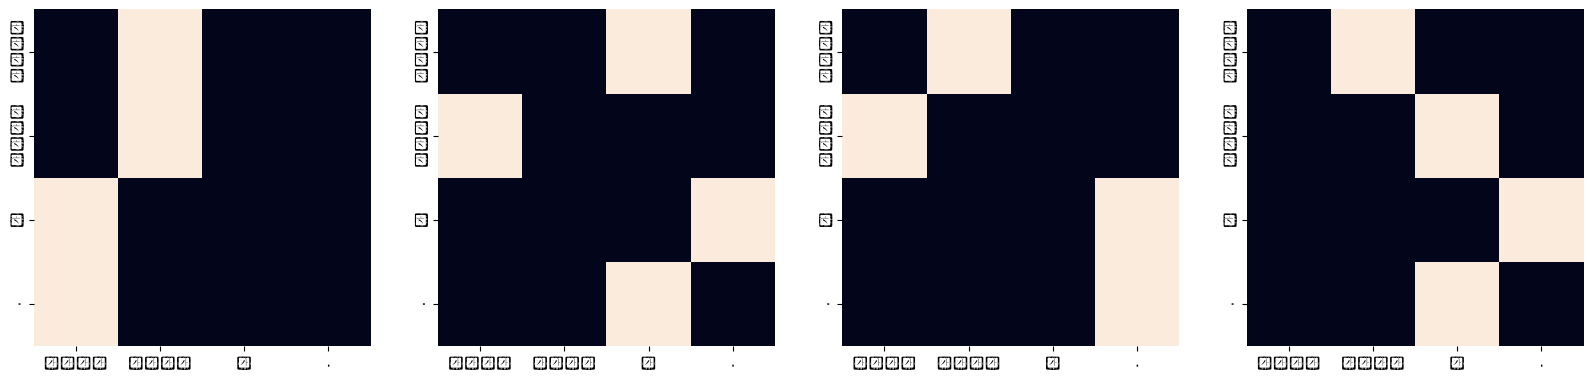

Encoder Self-Attention Layer 2


c:\Users\singf\Desktop\아이펠 모음\Seq2Seq\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\singf\Desktop\아이펠 모음\Seq2Seq\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 48148 (\N{HANGUL SYLLABLE BA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\singf\Desktop\아이펠 모음\Seq2Seq\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\singf\Desktop\아이펠 모음\Seq2Seq\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\singf\Desktop\아이펠 모음\Seq2Seq\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\singf\Desktop\아이펠 모음\Seq2Seq\.venv\Lib\site-packages\s

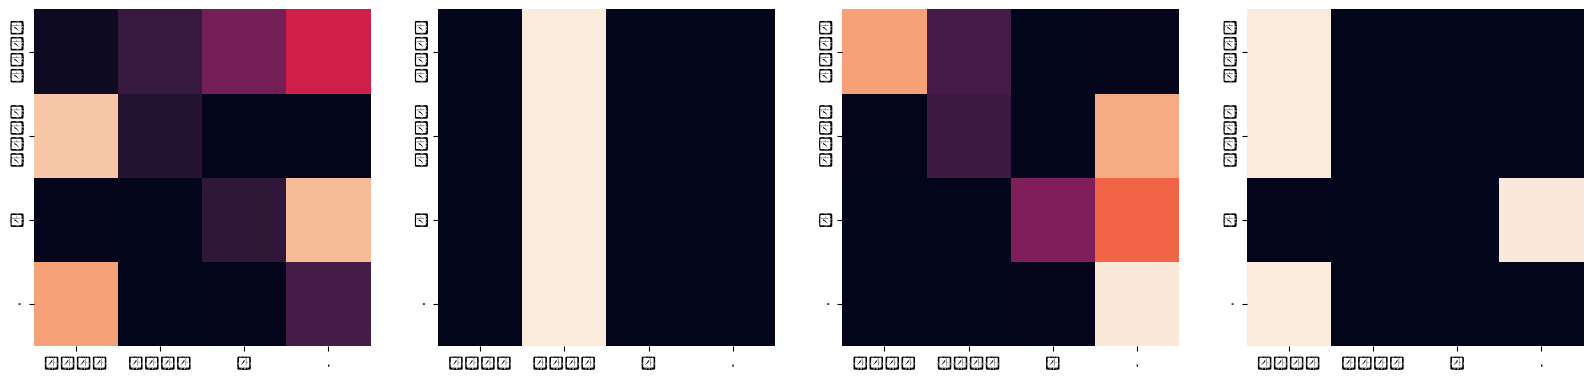

Decoder Self-Attention Layer 1


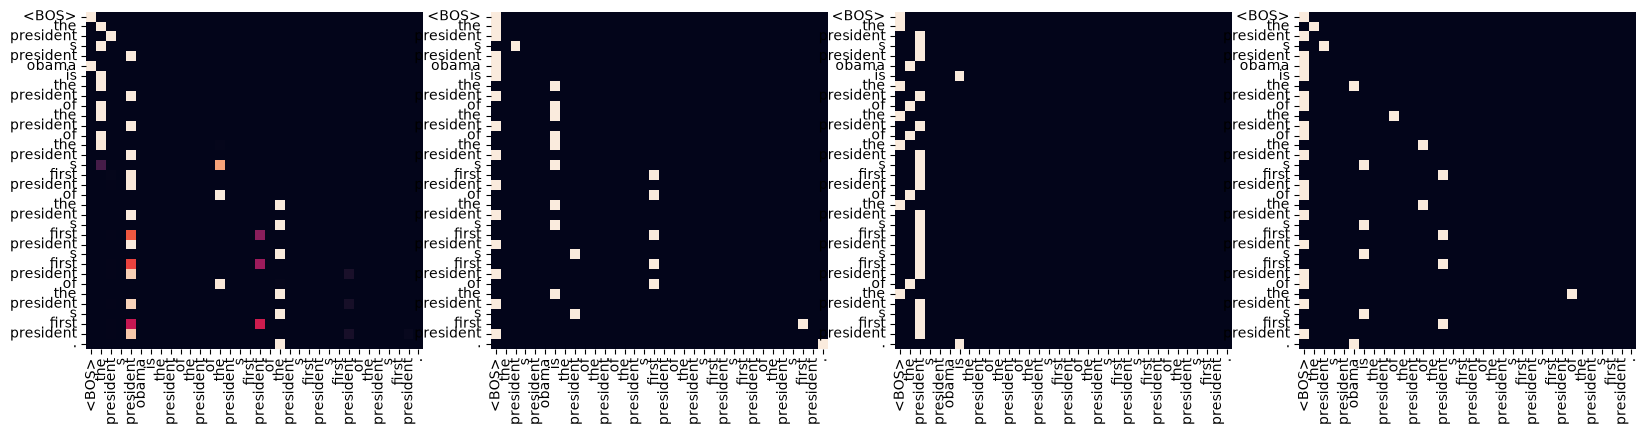

Decoder-Encoder Cross-Attention Layer 1


c:\Users\singf\Desktop\아이펠 모음\Seq2Seq\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\singf\Desktop\아이펠 모음\Seq2Seq\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 48148 (\N{HANGUL SYLLABLE BA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\singf\Desktop\아이펠 모음\Seq2Seq\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\singf\Desktop\아이펠 모음\Seq2Seq\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\singf\Desktop\아이펠 모음\Seq2Seq\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\singf\Desktop\아이펠 모음\Seq2Seq\.venv\Lib\site-packages\s

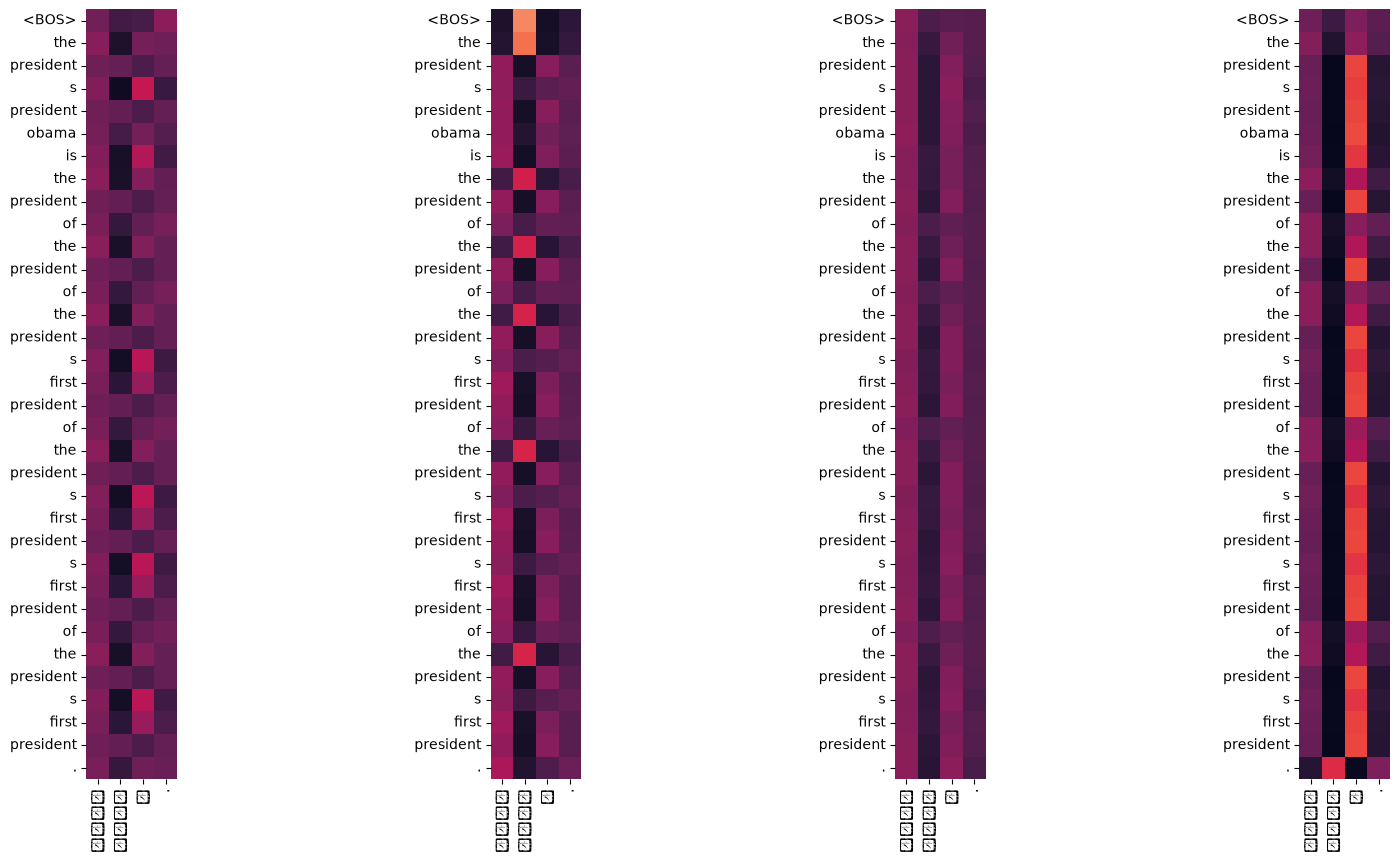

Decoder Self-Attention Layer 2


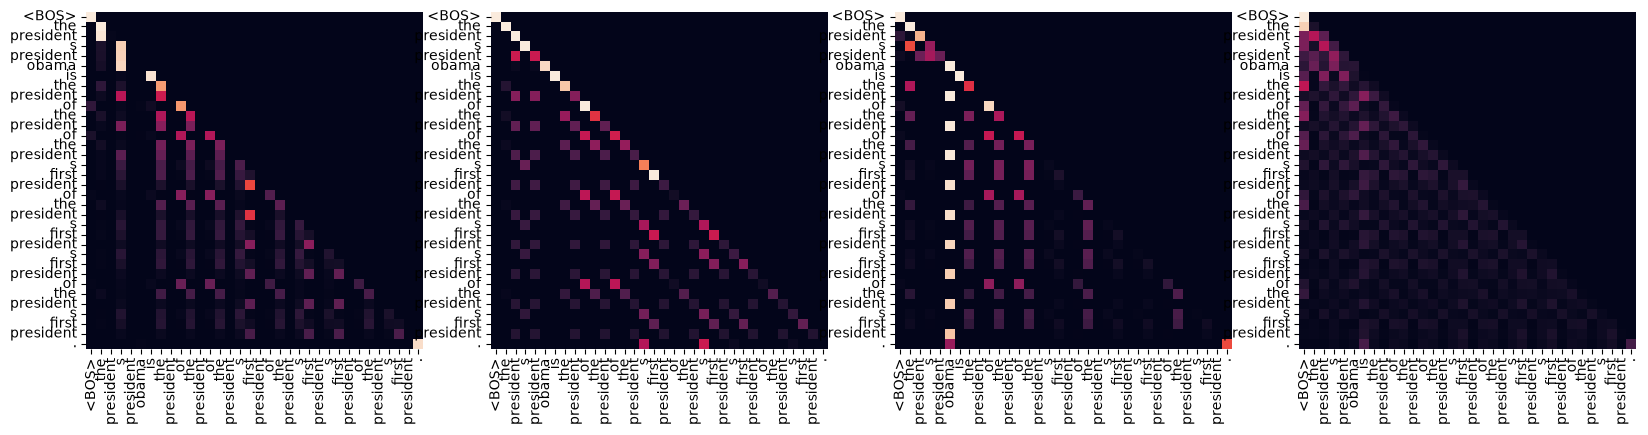

Decoder-Encoder Cross-Attention Layer 2


c:\Users\singf\Desktop\아이펠 모음\Seq2Seq\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\singf\Desktop\아이펠 모음\Seq2Seq\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 48148 (\N{HANGUL SYLLABLE BA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\singf\Desktop\아이펠 모음\Seq2Seq\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\singf\Desktop\아이펠 모음\Seq2Seq\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\singf\Desktop\아이펠 모음\Seq2Seq\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\singf\Desktop\아이펠 모음\Seq2Seq\.venv\Lib\site-packages\s

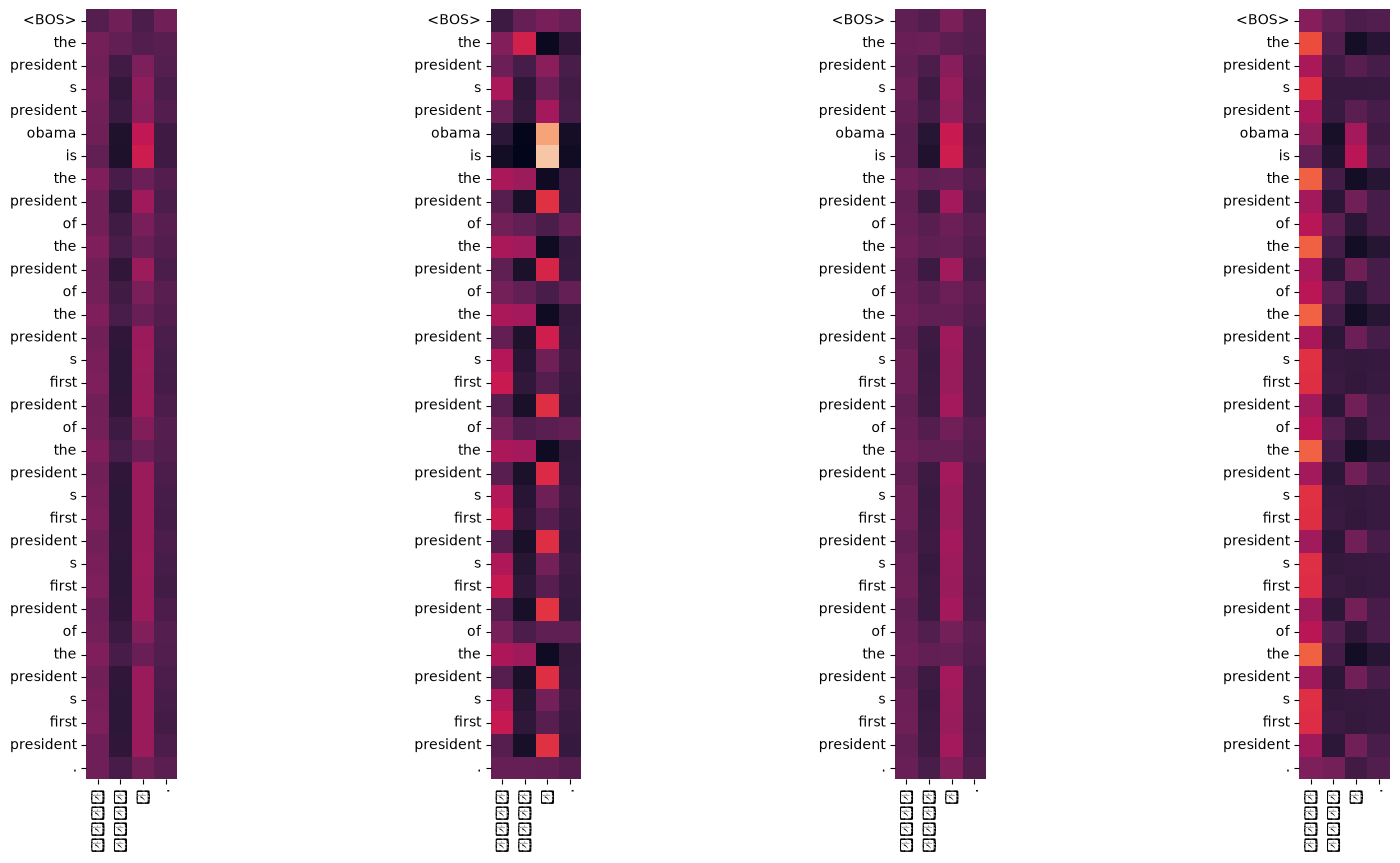

In [31]:
# --- 12. 최종 결과 확인: 번역 + Attention Map ---
# 학습이 모두 끝난 뒤, 첫 번째 예문에 대해 Attention Map까지 함께 그려서 결과를 뒷받침한다.
translate(examples[0], transformer, ko_tokenizer, en_tokenizer, plot_attention=True)


## 12. 결과 정리 & 루브릭 자가 점검

| 루브릭 항목 | 이 노트북에서 확인하는 위치 |
| --- | --- |
| 텍스트 데이터 전처리 | 2절(데이터 정제), 3절(문장 전처리) |
| 데이터 정제 / SentencePiece 토큰화 / 데이터셋 구축 | 3절 ~ 5절 |
| Transformer 모델이 정상 구동 | 6절 (모델 정의) + 8절(모델 생성 시 파라미터 수 출력) |
| 학습/추론 과정이 정상 진행되어 한-영 번역 기능 동작 | 9절(train_step), 10절(evaluate/translate), 11절(학습 루프) |
| 의미가 통하는 수준의 번역문 생성 | 11절 epoch별 예문 번역 출력, 12절 최종 번역 |
| 그럴듯한 번역문 + Attention Map으로 결과 뒷받침 | 12절 `visualize_attention` 결과 |

**다음에 시도해볼 것 (회고)**
- 번역 품질이 부족하면: EPOCHS를 늘리거나, `n_layers`/`d_model`을 키우거나, label smoothing을 손실 함수에 추가해볼 수 있다.
- 사실 그냥 EPOCHS 수가 터무니 없이 부족했다. 시간이슈.
- Greedy decoding 대신 beam search를 적용하면 번역 품질이 개선되는 경우가 많다.
- 검증(validation) 데이터를 따로 떼어 학습 loss뿐 아니라 검증 loss도 함께 모니터링하면 과적합 여부를 더 잘 확인할 수 있다.
